In [40]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import json
import os
import shutil
from sklearn.metrics import classification_report, confusion_matrix
from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

if torch.cuda.is_available():
    torch.cuda.empty_cache()
gc.collect()

Using device: cuda


6414

In [41]:
BASE_DATA = '/kaggle/input/datasets/zahrapriyono/research-methodology/Emotion Classification in E-Commerce/data/processed' if os.path.exists('/kaggle') else '../data/processed'
BASE_ARTIFACTS = '/kaggle/input/datasets/zahrapriyono/research-methodology/Emotion Classification in E-Commerce/data/processed' if os.path.exists('/kaggle') else '../data/processed'

train_path = f'{BASE_DATA}/train.csv'
val_path   = f'{BASE_DATA}/val.csv'
test_path  = f'{BASE_DATA}/test.csv'

LABEL_MAPPING_PATH  = f'{BASE_ARTIFACTS}/label_mapping.json'
CLASS_WEIGHTS_PATH  = f'{BASE_ARTIFACTS}/class_weights.json'

MAX_LENGTH     = 128
MODEL_CKPT     = 'xlm-roberta-base'
OUTPUT_DIR     = './xlmr_emotion'
PRED_OUT_PATH  = 'xlmr_predictions.csv'

if os.path.exists(OUTPUT_DIR):
    shutil.rmtree(OUTPUT_DIR)

In [42]:
df_train = pd.read_csv(train_path)
df_val   = pd.read_csv(val_path)
df_test  = pd.read_csv(test_path)

for df in [df_train, df_val, df_test]:
    df['text']  = df['text'].astype(str)
    df['label'] = df['label'].astype(int)

num_labels = df_train['label'].nunique()
print(f"Number of class/label: {num_labels}")

Number of class/label: 5


In [43]:
with open(LABEL_MAPPING_PATH) as f:
    label_map = json.load(f)  

id2label = {v: k for k, v in label_map.items()}
label2id = label_map
label_names = [id2label[i] for i in range(num_labels)]
print("Label order:", label_names)

with open(CLASS_WEIGHTS_PATH) as f:
    class_weights_dict = json.load(f)

weights = [class_weights_dict[str(i)] for i in range(num_labels)]

weight_tensor = torch.tensor(
    weights,
    dtype=torch.float
).to(device)

Label order: ['Anger', 'Fear', 'Happy', 'Love', 'Sadness']


In [44]:
dataset = DatasetDict({
    'train':      Dataset.from_pandas(df_train),
    'validation': Dataset.from_pandas(df_val),
    'test':       Dataset.from_pandas(df_test)
})

In [45]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_CKPT)

def preprocess_function(examples):
    return tokenizer(
        examples['text'],
        truncation=True,
        max_length=MAX_LENGTH,
        padding='max_length'
    )

tokenized_datasets = dataset.map(preprocess_function, batched=True)

Map:   0%|          | 0/4202 [00:00<?, ? examples/s]

Map:   0%|          | 0/525 [00:00<?, ? examples/s]

Map:   0%|          | 0/526 [00:00<?, ? examples/s]

In [46]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_CKPT,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id
)
model.to(device)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


XLMRobertaForSequenceClassification(
  (classifier): XLMRobertaClassificationHead(
    (dense): Linear(in_features=768, out_features=768, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
    (out_proj): Linear(in_features=768, out_features=5, bias=True)
  )
  (roberta): XLMRobertaModel(
    (embeddings): XLMRobertaEmbeddings(
      (word_embeddings): Embedding(250002, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): XLMRobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x XLMRobertaLayer(
          (attention): XLMRobertaAttention(
            (self): XLMRobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Li

In [47]:
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    preds = np.argmax(predictions, axis=1)
    from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
    return {
        "accuracy":  accuracy_score(labels, preds),
        "f1":        f1_score(labels, preds, average='macro', zero_division=0),
        "precision": precision_score(labels, preds, average='macro', zero_division=0),
        "recall":    recall_score(labels, preds, average='macro', zero_division=0),
    }

In [48]:
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.get("labels")
        outputs = model(**inputs)
        logits  = outputs.get("logits")
        loss    = nn.CrossEntropyLoss(weight=weight_tensor)(logits, labels)
        return (loss, outputs) if return_outputs else loss

In [49]:
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    learning_rate=3e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_steps=10,
    fp16=True,
    save_total_limit=2,
    report_to="none",
    seed=42,
    data_seed=42 
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets['train'],
    eval_dataset=tokenized_datasets['validation'],
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

print("--- Training XLM-RoBERTa ---")
trainer.train()

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


--- Training XLM-RoBERTa ---


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,1.081058,1.030912,0.575238,0.430586,0.616259,0.458933
2,0.848725,0.906613,0.657143,0.612930,0.634396,0.610754
3,0.697344,0.836748,0.681905,0.650173,0.656300,0.647462
4,0.652441,0.831318,0.655238,0.631590,0.627049,0.640740
5,0.576166,0.847342,0.659048,0.636352,0.632719,0.642323


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=660, training_loss=0.8673481601657289, metrics={'train_runtime': 455.057, 'train_samples_per_second': 46.17, 'train_steps_per_second': 1.45, 'total_flos': 1382028043292160.0, 'train_loss': 0.8673481601657289, 'epoch': 5.0})

In [50]:
print("--- Evaluasi pada Test Set ---")
predictions_output = trainer.predict(tokenized_datasets['test'])

y_pred = np.argmax(predictions_output.predictions, axis=1)
y_true = tokenized_datasets['test']['label']

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=label_names, digits=4))

--- Evaluasi pada Test Set ---


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]



Classification Report:
              precision    recall  f1-score   support

       Anger     0.5775    0.6119    0.5942        67
        Fear     0.4783    0.4944    0.4862        89
       Happy     0.8444    0.8686    0.8563       175
        Love     0.7500    0.7013    0.7248        77
     Sadness     0.7207    0.6780    0.6987       118

    accuracy                         0.7053       526
   macro avg     0.6742    0.6708    0.6721       526
weighted avg     0.7069    0.7053    0.7057       526



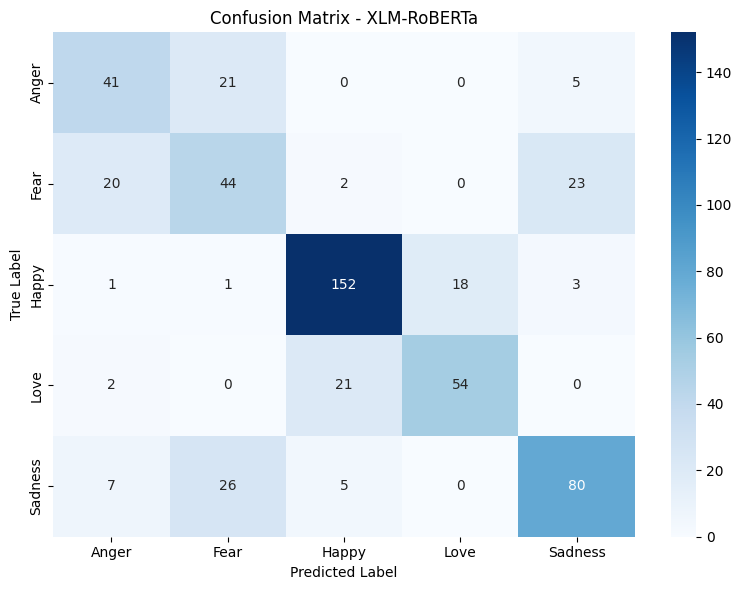

In [51]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=label_names,
    yticklabels=label_names
)
plt.title('Confusion Matrix - XLM-RoBERTa')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

In [52]:
df_test_copy = df_test.copy()
df_test_copy['predicted_label'] = y_pred
df_test_copy['predicted_emotion'] = [id2label[i] for i in y_pred]

probabilities = torch.nn.functional.softmax(
    torch.tensor(predictions_output.predictions, dtype=torch.float32), 
    dim=-1
).numpy()

for i in range(num_labels):
    df_test_copy[f'prob_{id2label[i]}'] = probabilities[:, i]

df_test_copy.to_csv(PRED_OUT_PATH, index=False)
print(f"Hasil prediksi disimpan ke: {PRED_OUT_PATH}")

Hasil prediksi disimpan ke: xlmr_predictions.csv
